
#**Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

##**Edición 2026**

---

# Trabajo práctico entregable - Parte 2

In [73]:
import io
import matplotlib
import matplotlib.pyplot as plt
import numpy
import pandas as pd
import seaborn as sns

#seaborn.set_context('talk')

## Lectura del dataset

En la notebook 00 se explican los detalles de la siguiente sección.

In [74]:
url = 'https://raw.githubusercontent.com/DiploDatos/AnalisisyVisualizacion/refs/heads/master/sysarmy_survey_2026_processed.csv'
df = pd.read_csv(url)

In [75]:
df[:3]

,work_province,work_dedication,work_contract_type,salary_monthly_BRUTO,salary_monthly_NETO,salary_in_usd,salary_last_dollar_value,salary_has_bonus,salary_bonus_tied_to,salary_inflation_adjustment,...,salary_on_call_duty_charge,aclara_el_numero_que_ingresaste_en_el_campo_anterior,salir_o_seguir_contestando_sobre_estudios,profile_age,profile_gender,profile_previous_survey,company_best_companies,sueldo_dolarizado,work_seniority,_sal
0,Mendoza,Full-Time,Staff (planta permanente),3000000.0,2400000.0,Mi sueldo está dolarizado (pero cobro en moned...,1300,No,Performance individual,No,...,NaN,NaN,NaN,45,Mujer Cis,Sí,NaN,True,Senior,3000000.0
1,Santa Fe,Full-Time,Contractor,5000000.0,5000000.0,Cobro todo el salario en dólares,1400,No,No recibo bono,No,...,NaN,NaN,NaN,50,Mujer Cis,Sí,NaN,True,Senior,5000000.0
2,Buenos Aires,Full-Time,Tercerizado (trabajo a través de consultora o ...,4600000.0,3600000.0,Cobro parte del salario en dólares,1436,No,No recibo bono,Uno,...,0.0,Porcentaje de mi sueldo bruto,Terminar encuesta,36,Mujer Cis,Sí,NaN,True,Senior,4600000.0


**Limpieza de datos**

Se aplica una limpieza consistente con la realizada en el Entregable Parte 1.

1. Eliminación de duplicados y nulos en columnas de interés.
2. Filtro de outliers por percentiles (1% y 99%) sobre 'salary_monthly_NETO'
3. Eliminación de registros con incosistencia NETO/BRUTO (ratio > 1.5)
4. Restricción de dedicación Full-Time.

In [76]:
# Columnas para la limpieza
relevant_columns = ['salary_monthly_NETO', 'salary_monthly_BRUTO', 'work_dedication', 'profile_gender']

df_raw = df.copy()
df = df.drop_duplicates()
df = df.dropna(subset=relevant_columns)
print(f"Registros tras eliminar duplicados y nulos: {len(df)}")

Registros tras eliminar duplicados y nulos: 4715


In [77]:
p01 = df['salary_monthly_NETO'].quantile(0.01)
p99 = df['salary_monthly_NETO'].quantile(0.99)

df = df[
    (df['salary_monthly_NETO'] >= p01) &
    (df['salary_monthly_NETO'] <= p99)
].copy()

print(f"Percentil 1%: {p01:,.0f} | Percentil 99%: {p99:,.0f}")
print(f"Registros tras filtro de percentiles: {len(df)}")

Percentil 1%: 389,398 | Percentil 99%: 11,837,200
Registros tras filtro de percentiles: 4619


In [78]:
df = df[
    df['salary_monthly_NETO'] / df['salary_monthly_BRUTO'] < 1.5
].copy()

print(f"Registros tras eliminar inconsistencias NETO/BRUTO: {len(df)}")

Registros tras eliminar inconsistencias NETO/BRUTO: 4581


In [79]:
df = df[df['work_dedication'] != 'Part-Time'].copy()
print(f"Registros finales (Full-Time): {len(df)}")

Registros finales (Full-Time): 4391


In [80]:
df.profile_gender.unique()

array(['Mujer Cis', 'Hombre Cis', 'Prefiero no decir', 'Trans', 'Queer',
       'No binarie', 'Agénero'], dtype=object)

In [81]:
df.loc[:,'profile_g'] = df.profile_gender.replace({'Hombre Cis': 'Varón cis','Mujer Cis': 'Mujer cis','Queer':'Diversidades','Trans':'Diversidades','Queer':'Diversidades','Lesbiana':'Diversidades','Agénero':'Diversidades'}).fillna(False)

In [82]:
alpha = 0.05

In [83]:
is_man = df.profile_g == 'Varón cis'
is_woman = df.profile_g == 'Mujer cis'


In [84]:
groupA = df[is_man].salary_monthly_NETO
groupB = df[is_woman].salary_monthly_NETO

In [85]:
print(f"Mean: {groupA.mean()}")
print(f"Median: {groupA.median()}")
print(f"Standard Deviation: {groupA.std()}")

Mean: 3344743.9226525277
Median: 2905969.5
Standard Deviation: 1912516.5426934694


In [86]:
print(f"Mean: {groupB.mean()}")
print(f"Median: {groupB.median()}")
print(f"Standard Deviation: {groupB.std()}")

Mean: 2761057.0305427248
Median: 2400000.0
Standard Deviation: 1507820.5560135248


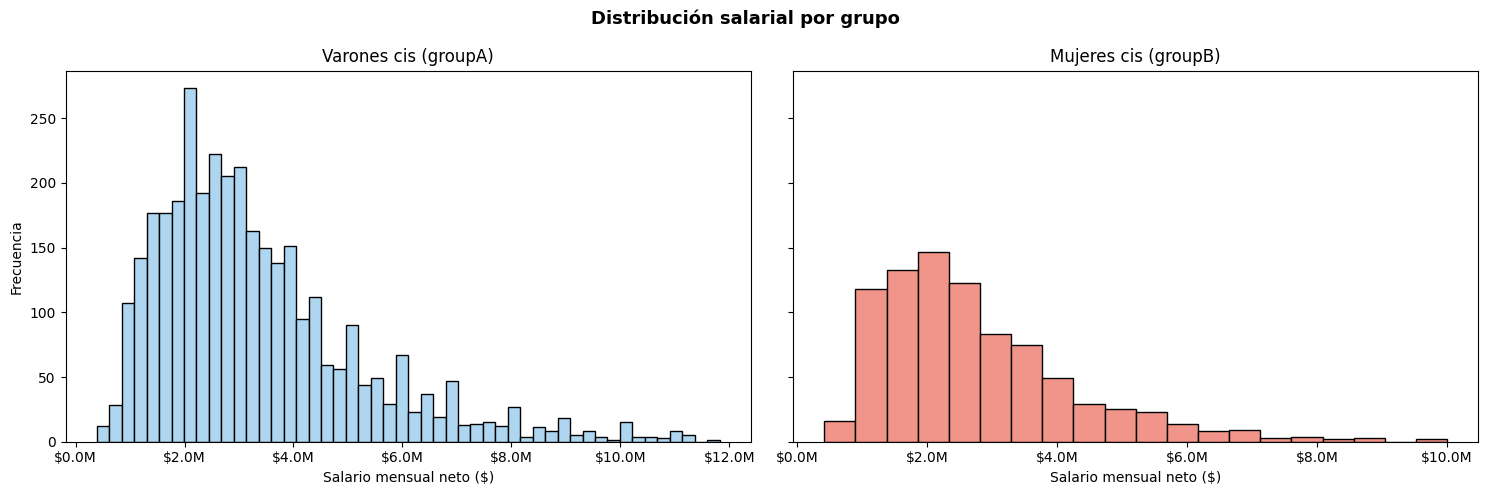

In [87]:


# Create the histograms
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

axes[0].hist(groupA, bins=50, color='#AED6F1', edgecolor='black')
axes[0].set_title('Varones cis (groupA)')
axes[0].set_xlabel('Salario mensual neto ($)')
axes[0].set_ylabel('Frecuencia')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

axes[1].hist(groupB, bins=20, color='#F1948A', edgecolor='black')
axes[1].set_title('Mujeres cis (groupB)')
axes[1].set_xlabel('Salario mensual neto ($)')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

plt.suptitle('Distribución salarial por grupo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()





## Ejercicio 1: Estimación

**Consigna:**  Calcular una estimación puntual y un intervalo de confianza de nivel (1-alpha) para la resta entre la media del salario Neto para Hombres y la media del salario Neto para mujeres (diferencia de las medias entre el grupoA y grupoB).
¿Cómo se relaciona este intervalo de confianza con el test de hipótesis para diferencia de medias?

Luego de aplicar los filtros, se calcula el tamaño de la muestra y la estimación puntual.

In [88]:
import scipy.stats as stats
import numpy as np

#Calculamos el tamaño de la muestra
print(f"Tamaño groupA (varones cis): {len(groupA)}")
print(f"Tamaño groupB (mujeres cis): {len(groupB)}")

# Estimación puntual
diff_means = groupA.mean() - groupB.mean()
print(f"\nEstimación puntual (diferencia de medias): {diff_means:,.2f}")

#Desvío estándar
print(f"Desvío estándar groupA: {groupA.std():,.2f}")
print(f"Desvío estándar groupB: {groupB.std():,.2f}")


Tamaño groupA (varones cis): 3442
Tamaño groupB (mujeres cis): 866

Estimación puntual (diferencia de medias): 583,686.89
Desvío estándar groupA: 1,912,516.54
Desvío estándar groupB: 1,507,820.56


Sabiendo que el Test de Levene es sensible al tamaño de la muestra, vemos que el grupo B es de menor tamaño, respecto al grupo A, entonces el test puede no tener suficiente potencia para detectar la diferencia de varianza aunque exista. Además, el desvío estándar es notablemente diferente entre ambas muestras. Se utiliza el Test de Welch.

In [89]:
# Intervalo de confianza (Welch)
nA = len(groupA)
nB = len(groupB)

se = np.sqrt(groupA.var(ddof=1)/nA + groupB.var(ddof=1)/nB)

df_welch = (groupA.var(ddof=1)/nA + groupB.var(ddof=1)/nB)**2 / \
           ((groupA.var(ddof=1)/nA)**2/(nA-1) + (groupB.var(ddof=1)/nB)**2/(nB-1))

t_crit = stats.t.ppf(1 - alpha/2, df=df_welch)

ci_lower = diff_means - t_crit * se
ci_upper = diff_means + t_crit * se

print(f"IC al {(1-alpha)*100:.0f}%: [{ci_lower:,.2f}, {ci_upper:,.2f}]")

IC al 95%: [464,572.68, 702,801.10]


El IC al 95% es [464,572.68, 702,801.10]. Como el intervalo no contiene el 0, hay evidencia estadísticamente signficiativa de que existe una diferencia salarial entre varones y mujeres cis. En promedio, los varones ganan entre 464k y 702k pesos más que las mujeres.

Respondiendo a la pregunta: **¿Cómo se relaciona este intervalo de confianza con el test de hipótesis para diferencia de medias?**


Si el IC no contiene el 0, entonces no es un valor plausible para la diferencia real, lo que equivale a rechazar $H_0$ en el test de hipótesis con ese mismo nivel de significancia. Un IC al 95% que excluye el 0 corresponde  a un p-valor < 0,05.

## Ejercicio 2: Test de hipótesis



### 2.1 Formalización

Describir formalmente los distintos componentes de un test de hipótesis para comprobar si la distribución de los salarios es distinta entre los grupos A y B.

**Hipótesis Nula**

$H_0=...$

**Estadístico (Pivote)**
  * Identificar el estadístico
  * Escribir qué distribución tiene bajo $H_0$


**Consideraciones:**

Los datos son los salarios observados en la encuesta (groupA y groupB),
que representan una muestra de la población de trabajadores tech en Argentina.

El modelo es el supuesto teórico que adoptamos para hacer inferencia:
bajo $H_0$, el estadístico t de Welch sigue una distribución t de Student
con los grados de libertad de Satterthwaite. Este modelo nos permite
calcular la probabilidad de observar una diferencia tan grande como la
encontrada si en realidad no hubiera brecha (p-valor).
Se tiene en cuenta que los datos nunca "prueban" nada por sí solos,
es el modelo el que nos da el marco para interpretar qué tan compatibles
son los datos con $H_0$.

**Hipótesis Nula y Alternativa**

La hipótesis nula es lo que asumimos verdadero hasta que nos damos cuenta de lo contrario.

$H_0=$ μ_A - μ_B = 0 → los salarios medios de varones y mujeres son iguales

$H_1=$ μ_A - μ_B ≠ 0→ los salarios medios de varones y mujeres son distintos


Es un test bilateral, ya que no asumimos a priori cuál grupo gana más.

**Estadístico (Pivote)**
Se utiliza el estadístico t de Welch:


$$t = \frac{\bar{X}_A - \bar{X}_B}{\sqrt{\frac{s_A^2}{n_A} + \frac{s_B^2}{n_B}}}$$

Se elige este test en lugar de Student porque:


*  Los tamaños de muestra con muy distinto ($n_A$ = 3442 , $n_B$ = 866).
*   Los desvíos estándar son notablemente diferentes.

**Distribución bajo $H_0$**

Bajo $H_0$ este estadístico sigue una distribución t de Student con grados de libertad calculados por la aproximación de Satterwhite:
$$df = \frac{\left(\frac{s_A^2}{n_A} + \frac{s_B^2}{n_B}\right)^2}{\frac{(s_A^2/n_A)^2}{n_A-1} + \frac{(s_B^2/n_B)^2}{n_B-1}}$$




**Nivel de significancia**

Se fija $a$ = 0.05, es decir, se acepta un 5% de probabilidad de rechazar $H_0$ cuando en realidad es verdadera (error de tipo I).



### 2.2 P-valor

1. Calcule el p-valor y decida si rechazar o no la hipótesis nula.
2. Interprete el resultado.

Links útiles:
* [Test de hipótesis usando scipy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html)
* [Test de Welch](http://daniellakens.blogspot.com/2015/01/always-use-welchs-t-test-instead-of.html)

In [90]:
from scipy.stats import ttest_ind

resultado = ttest_ind(groupA, groupB, equal_var=False)

print(f"Estadístico t: {resultado.statistic:.4f}")
print(f"Grados de libertad: {resultado.df:.4f}")
print(f"P-valor: {resultado.pvalue:.6f}")

if resultado.pvalue < alpha:
    print(f"\n→ p-valor ({resultado.pvalue:.6f}) < alpha ({alpha}) → Se rechaza H₀")
    print("  Hay evidencia estadística de diferencia salarial entre grupos.")
else:
    print(f"\n→ p-valor ({resultado.pvalue:.6f}) >= alpha ({alpha}) → No se rechaza H₀")
    print("  No hay evidencia suficiente de diferencia salarial entre grupos.")

# Verificación: el IC debe coincidir con el del Ejercicio 1
ci = resultado.confidence_interval(confidence_level=1-alpha)
print(f"\nIC al {(1-alpha)*100:.0f}% (verificación): [{ci.low:,.2f}, {ci.high:,.2f}]")

Estadístico t: 9.6114
Grados de libertad: 1639.4688
P-valor: 0.000000

→ p-valor (0.000000) < alpha (0.05) → Se rechaza H₀
  Hay evidencia estadística de diferencia salarial entre grupos.

IC al 95% (verificación): [464,572.68, 702,801.10]


Interpretación:

*   El estadístico t indica cuántos desvíos estándar está la diferencia observada respecto de lo esperado bajo $H_0$.
*   El p-valor es la probabilidad de observar una diferencia tan extrema como la encontrada, asumiendo que $H_0$ es verdadera.
*   Como p-valor < 0.05, rechazamos $H_0$.




Como complemento al test de Welch, se aplica Mann-Whitney U, una prueba no paramétrica que compara las distribuciones completas sin asumir normalidad. Es útil dado que los salarios presentan asimetría incluso tras la limpieza. Si ambos tests coinciden en rechazar $H_0$, el resultado es más robusto.

In [91]:
from scipy.stats import mannwhitneyu

stat_mw, p_mw = mannwhitneyu(groupA, groupB, alternative='two-sided')
print(f"Mann-Whitney U: estadístico={stat_mw:.2f}, p-valor={p_mw:.6f}")

if p_mw < alpha:
    print(f"→ p-valor ({p_mw:.6f}) < alpha ({alpha}) → Se rechaza H₀")
    print("  Hay evidencia de diferencia entre las distribuciones.")

Mann-Whitney U: estadístico=1765815.00, p-valor=0.000000
→ p-valor (0.000000) < alpha (0.05) → Se rechaza H₀
  Hay evidencia de diferencia entre las distribuciones.


**Conclusión:**

Con un nivel de significancia del 5%, hay evidencia estadística de que los salarios medios netos de varones cis y mujeres cis son distintos. La diferencia estimada es de $583.686,89; con un IC al 95% de [464.572.68 ; 702.801,10], lo que indica que los varones ganan en promedio más que las mujeres en la muestra analizada.

El IC coincide con el calculado en el Ej 1, lo que confirma la equivalencia entre ambos enfoques.


### [Opcional] 2.3 Potencia del test

Nuestra muestra, ¿era lo suficientemente grande para detectar si existe o no una diferencia entre los grupos?

1. Utilice la función `tt_ind_solve_power` para calcular el tamaño necesario de la muestra para un poder estadístico de 0.8, 0.9 y 0.95, asumiendo una significancia estadística de 0.05.
2. ¿Cómo intepretan el poder estadístico de un test? Dado su conocimiento de dominio sobre los datos, ¿les parece que esta muestra es lo suficientemente grande para ser representativo de la tendencia general? ¿y para utilizarlo en un juicio penal contra una empresa XX por una causa de discriminación?

[Documentación](https://www.statsmodels.org/stable/generated/statsmodels.stats.power.tt_ind_solve_power.html)

NOTA: este análisis debería hacerse ANTES de recolectar los datos.

**¿Qué es la potencia? ¿Cómo se interpreta el poder estadístico de un test?**

La potencia es la probabilidad de detectar una diferencia real cuando realmente existe, es decir, la probabilidad de rechazar $H_0$ cuando $H_0$ es falsa.

Una potencia baja significa un riesgo alto de cometer un error de tipo II (no detectar una diferencia real que si existe). Convencionalmente se busca una potencia de al menos 0,8.
Este análisis debería realizarse antes de recolectar los datos, para determinar el tamaño muestral necesario y asegurarse de que el estudio tenga suficiente capacidad para detectar el efecto de interés.

In [92]:
from statsmodels.stats.power import tt_ind_solve_power, TTestIndPower
import numpy as np
import pandas as pd

# Effect size de Cohen (desvío estándar pooled)
nA = len(groupA)
nB = len(groupB)
pooled_std = np.sqrt(((nA - 1) * groupA.std()**2 + (nB - 1) * groupB.std()**2) / (nA + nB - 2))
effect_size = (groupA.mean() - groupB.mean()) / pooled_std
ratio = nB / nA

print(f"Effect size (d de Cohen, pooled): {effect_size:.4f}")
print(f"Interpretación: ", end="")
if effect_size < 0.2:
    print("efecto muy pequeño")
elif effect_size < 0.5:
    print("efecto pequeño-moderado")
elif effect_size < 0.8:
    print("efecto moderado")
else:
    print("efecto grande")
print(f"Ratio (nB/nA): {ratio:.4f}")
print(f"Tamaño actual groupA: {nA}")
print(f"Tamaño actual groupB: {nB}")
print()

# Tabla de tamaños necesarios
resultados = []
for power_objetivo in [0.8, 0.9, 0.95]:
    n_necesario = tt_ind_solve_power(
        effect_size=effect_size,
        nobs1=None,
        alpha=0.05,
        power=power_objetivo,
        ratio=ratio,
        alternative='two-sided'
    )
    resultados.append({
        'Potencia objetivo': power_objetivo,
        'n mínimo groupA': int(n_necesario),
        'n actual groupA': nA,
        'n mínimo groupB': int(n_necesario * ratio),
        'n actual groupB': nB,
        '¿Suficiente?': '✅' if nA >= n_necesario else '❌'
    })

df_power = pd.DataFrame(resultados)
display(df_power)

Effect size (d de Cohen, pooled): 0.3175
Interpretación: efecto pequeño-moderado
Ratio (nB/nA): 0.2516
Tamaño actual groupA: 3442
Tamaño actual groupB: 866



,Potencia objetivo,n mínimo groupA,n actual groupA,n mínimo groupB,n actual groupB,¿Suficiente?
0,0.80,388,3442,97,866,✅
1,0.90,520,3442,130,866,✅
2,0.95,642,3442,161,866,✅


In [93]:
analysis = TTestIndPower()
actual_power = analysis.power(
    effect_size=effect_size,
    nobs1=nA,
    ratio=ratio,
    alpha=alpha
)
print(f"Potencia actual del test: {actual_power:.4f}")

Potencia actual del test: 1.0000


**Interpretación del análisis de potencia:**

Se emplea D de Cohen, para determinar que tan grande es la diferencia entre ambas muestras.   
**D de Cohen  = 0.3175** corresponde a un efecto pequeño-moderado según la escala de Cohen (pequeño = 0.2, mediano = 0.5, grande =0.8). Esto significa que la diferencia salarial entre varones y mujeres cis existe, pero no es muy grande en términos relativos al desvío estándar combinado de ambos grupos.

**Tabla de tamaños muestrales:** para los tres niveles de potencia evaluados, los tamaños actuales superan ampliamente el mínimo requerido en todos los casos:


*   Para la potencia 0.80 se necesitan 388 en groupA y 97 en grupoB.
*   Para potencia 0.90 se necesitan 520 en groupA y 130 en groupB.
*   Para potencia 0.95 se necesitan 642 en groupA y 161 en groupB.

Contamos con 3442 y 866, por lo que la muestra es más que suficiente para detectar la diferencia real del tamaño observado.

**Potencia actual = 1.0000:** con los tamaños muestrales disponibles, el test tiene potencia prácticamente perfecta. Si la diferencia salarial existe en la población, nuestro test la detectaría prácticamente siempre.

**¿Es suficiente para ser representativo de la tendencia general?**

Estadísticamente si, pero la muestra proviene de una encuesta voluntaria de sysarmy, lo que introduce sesgos de selección. No es aleatoria ni representativa de toda la industria tecnológica argentina, por que lo que los resultados deben interpretarse con cautela.

**¿Es suficiente para un juicio por discriminación?**

No. A pesar de alta potencia, para uso legal se requeriría una muestra aleatoria y representativa, además de controlar otras variables como rol, seniority y empresa, para poder establecer causalidad y no solo asociación estadística.

## Ejercicio 3: Comunicación y visualización

**Consigna:** Seleccionen un resultado que les parezca relevante a partir de alguno de los ejercicios del entregable. Diseñe e implemente una comunicación en base a este mensaje, en un archivo PDF.

Elija las palabras y visualización más adecuada para que la comunicación sea entendible, efectiva y se dapte a UNA de las siguientes situaciones:

1. Una sección en un artículo de difusión a presentar como parte de una organización sin fines de lucro.
No más de 1 página A4 (o dos si los gráficos son muy grandes).
  1. Ejemplo: Alguna de las secciones [Los ecosistemas de emprendimiento de América Latina y el Caribe frente al COVID-19: Impactos, necesidades y recomendaciones](https://publications.iadb.org/es/los-ecosistemas-de-emprendimiento-de-america-latina-y-el-caribe-frente-al-covid-19-impactos-necesidades-y-recomendaciones), por ejemplo la sección *2.2. Reacciones de los emprendedores*.
  2. Ejemplo: Alguna de las secciones de [The state of gender pay gap in 2021](https://www.payscale.com/data/gender-pay-gap?tk=carousel-ps-rc-job)
  3. Puntos clave:
    1. Simpleza de los gráficos.
    2. Comunicación en lenguaje simple a personas que no son necesariamente expertos de dominio.
    2. Selección de UNA oración sobre la que se hace énfasis.
    3. No es necesario que mencionen objetivos ni descripciones del conjunto de datos, se supone que eso ya estaría explicado en otras secciones del informe.

2. Una publicación científica o reporte técnico interno. No más de una página A4:
  2. Ejemplo: La sección de resultados de [IZA DP No. 12914: The Impact of a Minimum Wage Change on the Distribution of Wages and Household Income](https://www.iza.org/publications/dp/12914/the-impact-of-a-minimum-wage-change-on-the-distribution-of-wages-and-household-income).
  2. Ejemplo: Alguna de las secciones de [Temporary reduction in daily global CO2 emissions during the COVID-19 forced confinement](https://www.nature.com/articles/s41558-020-0797-x)
  3. Puntos clave:
    3. Nivel de detalle técnico requerido. Es necesario justificar la validez del análisis.
    4. La idea presentada puede ser más compleja. Pueden asumir que la audiencia tiene conocimiento técnico y va a analizar las visualizaciones en detalle.
    5. Pueden presentar más en detalle las limitaciones del análisis (significancia estadística, etc.)
    2. No es necesario que mencionen objetivos ni descripciones del conjunto de datos, se supone que eso ya estaría explicado en otras secciones del informe.

3. Un tweet (o post de LinkedIn) para la cuenta de su empresa consultora que hace análisis de datos. El objetivo es promocionar un análisis de datos abiertos que van a incluir en su portfolio:
  1. Ejemplo: [Comparación vacunas covid](https://twitter.com/infobeautiful/status/1381577746527236098?s=20)
  2. Ejemplo: [Tweet del BID](https://twitter.com/el_BID/status/1388508583944507396?s=20). Lo valioso de este tweet es que usaron un único número para transmitir un mensaje. Puede ser algo así, o con un gráfico muy simple.
  3. Ejemplo: [Cambio climático](https://twitter.com/UNFCCC/status/1387732156190011394?s=20) Es un muy buen ejemplo, excepto que el gráfico no se lee nada y hay que entrar a la publicación original.
  3. Ejemplo: [¿Cuánto están los programadores en las empresas?](https://www.linkedin.com/posts/denis-rothman-0b034043_tech-career-work-activity-6793861923269054464-gS6y) (No verificamos la veracidad o seriedad de la fuente).
  4. Puntos clave:
    1. Su audiencia no va a mirar la visualización por más de unos segundos, y no tiene conocimiento técnico.
  3. Tienen que incluir además una *breve* descripción de cómo obtuvieron los datos que están presentando, que no entraría en el tweet.


**Ej 3: Comunicación y Visualización**

**Análisis de la brecha salarial por nivel de seniority.**

Se construyeron dos medidas de brecha salarial entre varones y mujeres cis para cada nivel de seniority:


*   Brecha absoluta: media varones - media muejeres (en pesos)
*   Brecha ratio: media varones /media mujeres (veces).



In [94]:
import pandas as pd
import numpy as np

# Filtrar seniorities y géneros de interés
seniorities = ['Junior', 'Semi-Senior', 'Senior']

df_brecha = df[
    df['work_seniority'].isin(seniorities) &
    df['profile_g'].isin(['Varón cis', 'Mujer cis'])
].copy()

# Calcular media por seniority y género
resumen = df_brecha.groupby(['work_seniority', 'profile_g'])['salary_monthly_NETO'].mean().unstack()

# Nueva variable: brecha como diferencia y como ratio
resumen['brecha_diferencia'] = resumen['Varón cis'] - resumen['Mujer cis']
resumen['brecha_ratio'] = resumen['Varón cis'] / resumen['Mujer cis']

# Ordenar por seniority
resumen = resumen.loc[seniorities]
resumen_display = resumen.copy()
resumen_display['Mujer cis'] = resumen_display['Mujer cis'].apply(lambda x: f'${x/1e6:.2f}M')
resumen_display['Varón cis'] = resumen_display['Varón cis'].apply(lambda x: f'${x/1e6:.2f}M')
resumen_display['brecha_diferencia'] = resumen_display['brecha_diferencia'].apply(lambda x: f'${x/1e3:.0f}k')
resumen_display['brecha_ratio'] = resumen_display['brecha_ratio'].apply(lambda x: f'{x:.2f}x')

resumen_display.columns = ['Media Mujer cis', 'Media Varón cis', 'Brecha absoluta', 'Brecha ratio']
display(resumen_display)

,Media Mujer cis,Media Varón cis,Brecha absoluta,Brecha ratio
work_seniority,,,,
Junior,$1.72M,$1.79M,$78k,1.05x
Semi-Senior,$2.33M,$2.67M,$345k,1.15x
Senior,$3.42M,$3.91M,$492k,1.14x


**Interpretación:**

Se observa que la brecha salarial no es uniforme entre niveles de seniority. En Junior es casi inexistente ($78k, ratio 1.05x), lo que sugiere que al inicio de la carrera las diferencias salariales por género son pequeñas.

Sin embargo, la brecha se amplía considerablemente a partir de Semi-Senior ( 345k, ratio 1.15x) y se mantiene elevada en Senior ($492k, ratio 1.14x). Esto indica que la brecha crece con la experiencia y se estabiliza en los niveles más altos.

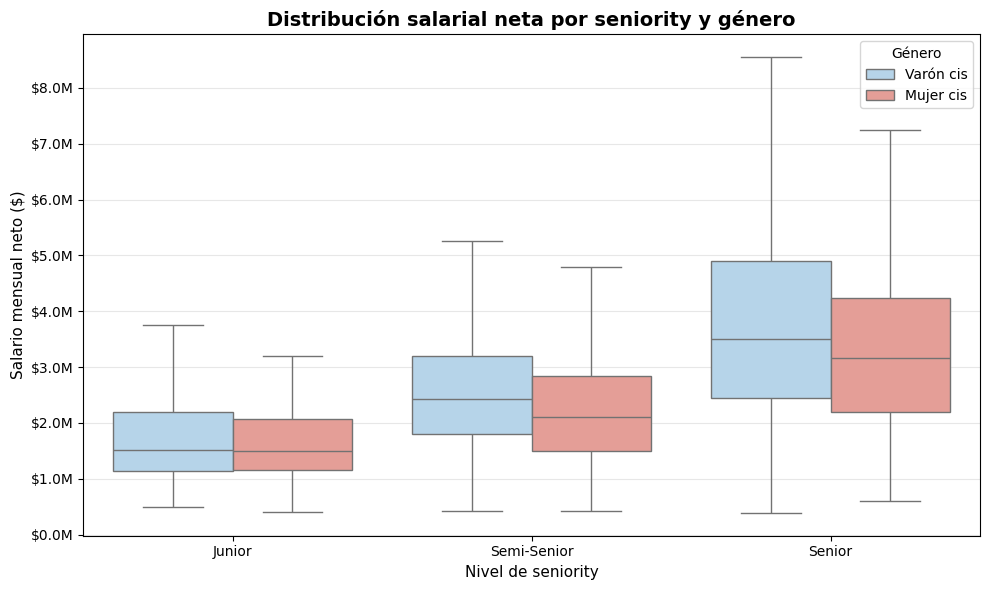

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df_brecha,
    x='work_seniority',
    y='salary_monthly_NETO',
    hue='profile_g',
    order=seniorities,
    hue_order=['Varón cis', 'Mujer cis'],
    palette={'Varón cis': '#AED6F1', 'Mujer cis': '#F1948A'},
    showfliers=False,
    ax=ax
)

ax.set_title('Distribución salarial neta por seniority y género', fontsize=14, fontweight='bold')
ax.set_xlabel('Nivel de seniority', fontsize=11)
ax.set_ylabel('Salario mensual neto ($)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.legend(title='Género')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('boxplot_seniority_genero.png', dpi=300, bbox_inches='tight')
plt.show()

En el gráfico de brecha absoluta muestra una tendencia con respecto a que la diferencia en pesos crece con el seniority. En Junior es de 78k, casi despreciable. En Semi- Senior salta a 345k y en Senior alcanza los 492k. Esto singifica que en términos monetarios en la brecha, se hace más costosa para las mujeres a medida que avanzan en su carrera.

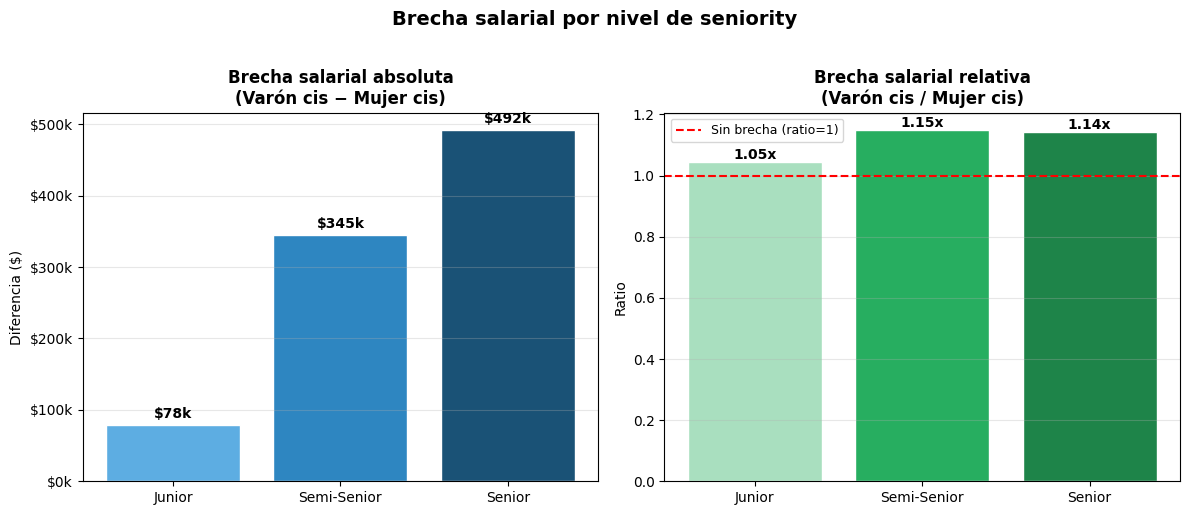

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Brecha como diferencia
axes[0].bar(
    seniorities,
    resumen['brecha_diferencia'],
    color=['#5DADE2', '#2E86C1', '#1A5276'],
    edgecolor='white'
)
axes[0].set_title('Brecha salarial absoluta\n(Varón cis − Mujer cis)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Diferencia ($)', fontsize=10)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
axes[0].grid(axis='y', alpha=0.3)

# Agregar etiquetas encima de cada barra
for i, (seniority, val) in enumerate(zip(seniorities, resumen['brecha_diferencia'])):
    axes[0].text(i, val + 10000, f'${val/1e3:.0f}k', ha='center', fontsize=10, fontweight='bold')

# Brecha como ratio
axes[1].bar(
    seniorities,
    resumen['brecha_ratio'],
    color=['#A9DFBF', '#27AE60', '#1E8449'],
    edgecolor='white'
)
axes[1].axhline(y=1, color='red', linestyle='--', linewidth=1.5, label='Sin brecha (ratio=1)')
axes[1].set_title('Brecha salarial relativa\n(Varón cis / Mujer cis)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Ratio', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

# Agregar etiquetas encima de cada barra
for i, (seniority, val) in enumerate(zip(seniorities, resumen['brecha_ratio'])):
    axes[1].text(i, val + 0.01, f'{val:.2f}x', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Brecha salarial por nivel de seniority', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('barplot_brecha_seniority.png', dpi=300, bbox_inches='tight')
plt.show()

En el gráfico de ratio, se observa que entre Semi-Senior (1.15x) y Senior (1.14 x) el ratio es prácticamente igual, lo que indica que en términos relativos la brecha no sigue creciendo después de Semi-Senior. La diferencia absoluta mayor en Senior se explica porque los salarios base son más altos, no porque la desigualdad relativa sea peor.

La línea roja punteada (ratio =1) representa la ausencia de brecha. Los tres niveles están por encima de ella, confirmando que en ningún caso los salarios son iguales en promedio.